## Ejercicio Time Series Forecast
Para este ejercicio vamos a predecir cuál será la demanda de pasajeros de una aerolínea, para poder anticiparse a las contrataciones de personal, mantenimiento de las aeronaves y gestión de inventario y comidas.

Para ello, se pide:
1. Carga datos (AirPassengers.csv) y representa la serie. ¿Hay seasonality? ¿Cada cuanto?
2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window con el valor de seasonality obtenido en el apartado anterior. Tienes que usar la función rolling() del DataFrame.
3. Comprueba de manera estadística si la serie es o no stationary.
4. Aplica una transformación logarítmica sobre los datos para mejorar el proceso de transformación de tu time series a stationary. Acuérdate después del forecast de invertir la transformación.
5. Divide en train y test. Guarda 20 muestras para test.
6. Crea tu primer modelo ARIMA. Habrá varias combinaciones en función de sus hiperparámetros... Mide el MAE y RMSE del modelo en predicción. Ten en cuenta el parámetro "m" de la función ARIMA, mediante el cual se establece el seasonality.
7. Representa en una gráfica los datos de test y tus predicciones.
8. Prueba un decission tree y un random forest, a ver qué rendimiento presentan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Carga datos y representa la serie

In [2]:
df = pd.read_csv('data/AirPassengers.csv')
df.head()

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [ ]:
# Convierte la columna 'date' al formato oficial de fecha de pandas (datetime64)
# Esto permite que Python entienda el orden cronológico y facilite el análisis temporal
df['date'] = pd.to_datetime(df['date'])


In [ ]:
# Establece la columna 'date' como el índice (eje principal) del DataFrame
# 'inplace=True' aplica el cambio permanentemente en el objeto original
df.set_index('date', inplace=True)


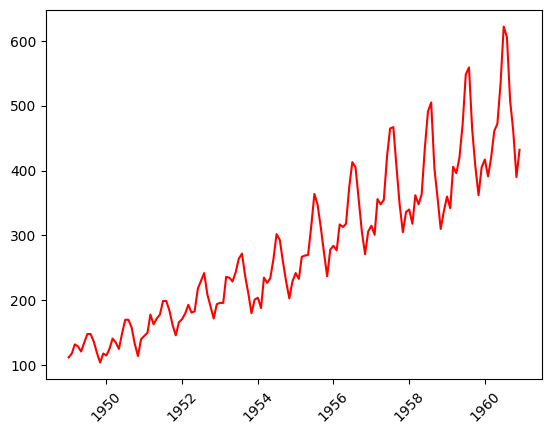

In [ ]:
# Grafica los datos usando el índice de fechas para el eje X y la columna 'value' para el eje Y
# '-r' dibuja una línea continua de color rojo
plt.plot(df.index, df['value'], '-r')

# Rota las etiquetas de las fechas en el eje X 45 grados
# Esto evita que los textos se amontonen y los hace mucho más legibles
plt.xticks(rotation=45);


## 2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window comparando el valor de seasonality obtenido en el apartado anterior

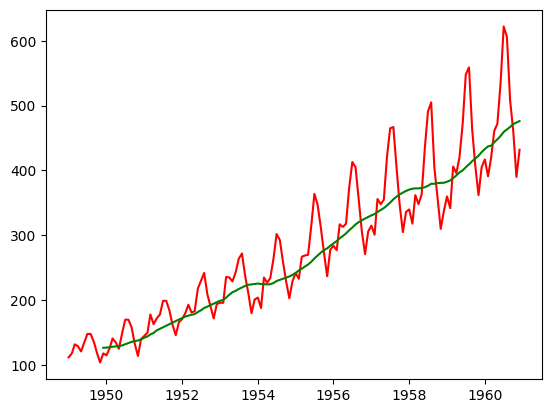

In [ ]:
plt.plot(df['value'], '-r')
plt.plot(df['value'].rolling(window=12).mean(), '-g');# Grafica la serie original de precios en color rojo ('-r')
plt.plot(df['value'], '-r')

# Calcula y grafica la media móvil de los últimos 12 meses en color verde ('-g')
# El parámetro 'window=12' agrupa los datos de año en año para suavizar la serie
plt.plot(df['value'].rolling(window=12).mean(), '-g');


## 3. Comprueba de manera estadística si la serie es o no estacionaria.

In [7]:
from statsmodels.tsa.stattools import adfuller, kpss

In [ ]:
# Ejecuta la prueba de Dickey-Fuller aumentada (ADF) sobre los valores de la serie
# Se utiliza .values para extraer el arreglo numérico sin el índice de fechas
result = adfuller(df['value'].values)

# Extrae el p-valor (p-value), que es el segundo elemento del resultado (índice 1)
# Si este valor es mayor a 0.05, significa que la serie tiene tendencia o estacionalidad
result[1]    # La serie no es estacionaria


np.float64(0.991880243437641)

## 4. Aplica una transformación logarítmica

In [ ]:
# Aplica una transformación logarítmica a la columna 'value' y guarda el resultado en 'value_log'
# np.log (logaritmo natural) ayuda a estabilizar la varianza cuando los picos crecen con el tiempo
df['value_log'] = np.log(df['value'])


In [10]:
df.head()

,value,value_log
date,,
1949-01-01,112,4.718499
1949-02-01,118,4.770685
1949-03-01,132,4.882802
1949-04-01,129,4.859812
1949-05-01,121,4.795791


## 5. Divide en train y test. Guarda 20 muestras para test.

In [ ]:
# Crea el conjunto de entrenamiento tomando todos los datos excepto los últimos 20 meses
# Se utiliza para que el modelo "aprenda" los patrones históricos
train = df['value_log'].iloc[:-20]

# Crea el conjunto de prueba tomando únicamente los últimos 20 meses
# Se reserva para evaluar qué tan buenas son las predicciones del modelo con datos que no ha visto
test = df['value_log'].iloc[-20:]


## 6. Crea tu primer modelo ARIMA

In [14]:
from pmdarima.arima import auto_arima
from pmdarima.arima import ARIMA

In [ ]:
# Ejecuta la búsqueda automática del mejor modelo ARIMA sobre los datos de entrenamiento
# Se configuran los rangos de búsqueda para los parámetros p (autorregresivo), q (media móvil) y d (diferenciación)
model = auto_arima(train,
                   start_p = 1,     # Orden inicial para la parte autorregresiva (p)
                   start_q = 1,     # Orden inicial para la parte de media móvil (q)
                   max_p = 5,       # Límite máximo de rezagos para p
                   max_q = 5,       # Límite máximo de rezagos para q
                   max_d = 3,       # Número máximo de diferenciaciones permitidas para hacer la serie estacionaria
                   trace=True)      # Muestra en pantalla el progreso de cada modelo probado (AIC, tiempo, etc.)


Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-208.997, Time=0.24 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-201.351, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-202.849, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-204.251, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-202.180, Time=0.02 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.36 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.37 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.29 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-204.379, Time=0.07 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-225.739, Time=0.35 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-229.588, Time=0.44 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-229.000, Time=0.35 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=-233.691, Time=0.46 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=-214.822, Time=0.23 sec
 ARIMA(5,1,2)(0,0,0)[0] intercept   : AIC=-232.7

In [ ]:
# Ajusta el modelo seleccionado a los datos de entrenamiento para aprender sus patrones
model.fit(train)

# Genera pronósticos para los próximos 20 periodos (pasos hacia adelante)
# El resultado se guarda en la variable 'predictions1'
predictions1 = model.predict(20)


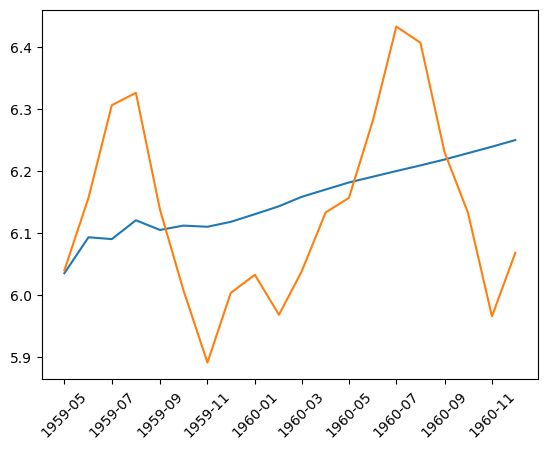

In [ ]:
# Grafica los valores predichos por el modelo para los últimos 20 meses
plt.plot(predictions1)

# Grafica los valores reales (el conjunto de prueba) para poder comparar la precisión
plt.plot(test)

# Rota las etiquetas de fecha del eje X 45 grados para que no se solapen
plt.xticks(rotation=45);


In [20]:
from sklearn.metrics import mean_squared_error

In [ ]:
# Busca el mejor modelo SARIMA incluyendo el componente estacional
model = auto_arima(train,
                    start_p=1,       # Orden inicial autorregresivo
                    start_q=1,       # Orden inicial de media móvil
                    max_d=3,         # Máximo de diferenciaciones
                    max_p=5,         # Límite de búsqueda para p
                    max_q=5,         # Límite de búsqueda para q
                    m = 12,          # Periodicidad estacional (12 meses para datos anuales)
                    trace=True,      # Muestra el progreso de la búsqueda
                    stepwise=True)   # Usa un algoritmo optimizado para ir más rápido

# Imprime el AIC (métrica de calidad) del mejor modelo encontrado
print(model.aic())

# Genera el pronóstico para los próximos 20 meses
predictions = model.predict(20)

# Calcula e imprime el Error Cuadrático Medio (MSE) comparando la realidad (test) con la predicción
print("mean_squared_error:", mean_squared_error(test, predictions))


Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,1,1)[12] intercept   : AIC=-409.584, Time=1.31 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=-290.649, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=-399.417, Time=1.08 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=-353.179, Time=0.45 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=-125.472, Time=0.02 sec
 ARIMA(1,0,1)(0,1,1)[12] intercept   : AIC=-411.631, Time=1.07 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=-384.170, Time=0.21 sec
 ARIMA(1,0,1)(0,1,2)[12] intercept   : AIC=-409.714, Time=2.95 sec
 ARIMA(1,0,1)(1,1,0)[12] intercept   : AIC=-405.268, Time=1.09 sec
 ARIMA(1,0,1)(1,1,2)[12] intercept   : AIC=-408.108, Time=2.26 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=-408.087, Time=0.46 sec
 ARIMA(2,0,1)(0,1,1)[12] intercept   : AIC=-410.728, Time=0.98 sec
 ARIMA(1,0,2)(0,1,1)[12] intercept   : AIC=-409.956, Time=1.64 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=-300.825, Time=0.16 sec
 ARIMA(0,0,2)(0,1,1

## 7. Representa en una gráfica los datos de test y tus predicciones.

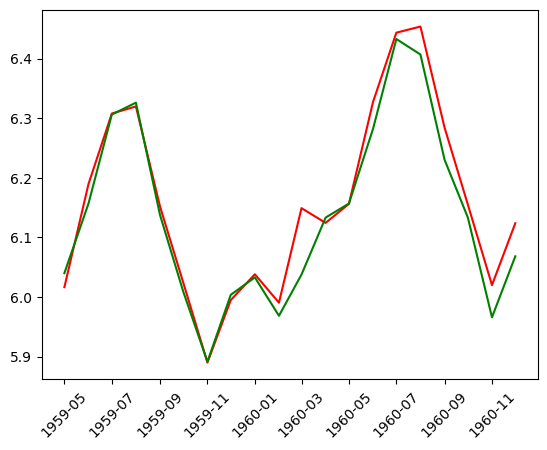

In [ ]:
# Grafica las predicciones del modelo SARIMA (con estacionalidad) en color rojo ('-r')
plt.plot(predictions, '-r')

# Grafica los valores reales del conjunto de prueba (test) en color verde ('-g')
plt.plot(test, '-g')

# Rota las etiquetas de las fechas 45 grados para mejorar la visualización
plt.xticks(rotation=45);


## 8. Prueba otros modelos supervisados, a ver qué performance presentan.

In [ ]:
# Crea una copia del DataFrame original para no modificar los datos base
df2 = df.copy()

# Crea 24 nuevas columnas, cada una representando el valor de hace 'i' meses
# El bucle va desde 24 hasta 1 (hacia atrás)
for i in range(24, 0, -1):
    # .shift(i) desplaza los datos hacia abajo para crear variables "lag" (retrasos)
    df2['t-'+str(i)] = df2['value'].shift(i)

# Elimina las primeras 24 filas, ya que al desplazar los datos contienen valores nulos (NaN)
df2.dropna(inplace=True)

# Muestra el nuevo DataFrame con las columnas de retrasos añadidas
df2


,value,value_log,t-24,t-23,t-22,t-21,t-20,t-19,t-18,t-17,...,t-10,t-9,t-8,t-7,t-6,t-5,t-4,t-3,t-2,t-1
date,,,,,,,,,,,,,,,,,,,,,
1951-01-01,145,4.976734,112.0,118.0,132.0,129.0,121.0,135.0,148.0,148.0,...,141.0,135.0,125.0,149.0,170.0,170.0,158.0,133.0,114.0,140.0
1951-02-01,150,5.010635,118.0,132.0,129.0,121.0,135.0,148.0,148.0,136.0,...,135.0,125.0,149.0,170.0,170.0,158.0,133.0,114.0,140.0,145.0
1951-03-01,178,5.181784,132.0,129.0,121.0,135.0,148.0,148.0,136.0,119.0,...,125.0,149.0,170.0,170.0,158.0,133.0,114.0,140.0,145.0,150.0
1951-04-01,163,5.093750,129.0,121.0,135.0,148.0,148.0,136.0,119.0,104.0,...,149.0,170.0,170.0,158.0,133.0,114.0,140.0,145.0,150.0,178.0
1951-05-01,172,5.147494,121.0,135.0,148.0,148.0,136.0,119.0,104.0,118.0,...,170.0,170.0,158.0,133.0,114.0,140.0,145.0,150.0,178.0,163.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1960-08-01,606,6.406880,505.0,404.0,359.0,310.0,337.0,360.0,342.0,406.0,...,407.0,362.0,405.0,417.0,391.0,419.0,461.0,472.0,535.0,622.0
1960-09-01,508,6.230481,404.0,359.0,310.0,337.0,360.0,342.0,406.0,396.0,...,362.0,405.0,417.0,391.0,419.0,461.0,472.0,535.0,622.0,606.0
1960-10-01,461,6.133398,359.0,310.0,337.0,360.0,342.0,406.0,396.0,420.0,...,405.0,417.0,391.0,419.0,461.0,472.0,535.0,622.0,606.0,508.0


In [ ]:
# Selecciona todas las columnas de "retrasos" (lags) como variables independientes (características)
# El '2:' indica que toma desde la tercera columna hasta el final, omitiendo las originales
x = df2.iloc[::, 2:]

# Define la variable dependiente (objetivo), que es el valor actual que queremos predecir
y = df2['value']


In [ ]:
# Divide las variables independientes (X) en entrenamiento (primeras 100 filas) y prueba (el resto)
x_train = x[:100]
x_test = x[100:]

# Divide la variable objetivo (y) de la misma forma para que coincidan con las filas de X
y_train = y[:100]
y_test = y[100:]


In [ ]:
# Imprime las dimensiones (filas y columnas) de cada conjunto de datos
# Esto sirve para confirmar que la división es correcta y que el número de filas coincide entre X e Y
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)


(100, 24) (20, 24) (100,) (20,)


In [30]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# Crea una instancia del modelo de Bosques Aleatorios (Random Forest) para regresión
# 'max_depth=5' limita la profundidad de los árboles para evitar que el modelo se 
# sobreajuste (overfitting) y memorice demasiado los datos de entrenamiento
model_rf = RandomForestRegressor(max_depth=5)


In [ ]:
# Crea una instancia del modelo de Bosques Aleatorios (Random Forest) para regresión
# 'max_depth=5' limita la profundidad de los árboles para evitar que el modelo se 
# sobreajuste (overfitting) y memorice demasiado los datos de entrenamiento
model_rf = RandomForestRegressor(max_depth=5)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [ ]:
# Genera las predicciones de precios utilizando el modelo de Bosque Aleatorio ya entrenado
# Se le pasan las características del conjunto de prueba (x_test) para obtener los valores estimados
predictions = model_rf.predict(x_test)


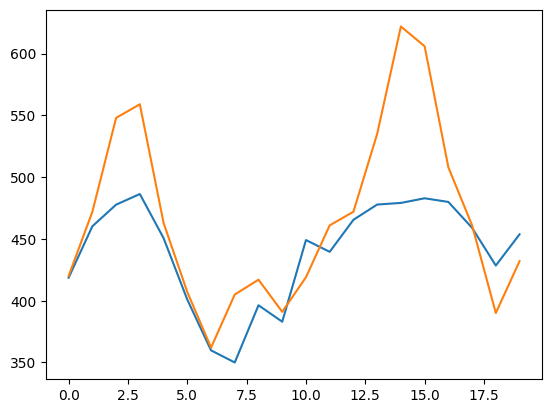

In [ ]:
# Grafica los valores predichos por el modelo Random Forest
plt.plot(predictions)

# Grafica los valores reales del conjunto de prueba
# Se usa .values para convertir la Serie de pandas en un array y que coincidan los ejes
plt.plot(y_test.values);
